# SWR detection

In [1]:
from pathlib import Path
import numpy as np
from Utilities.swr_detection import preprocess_lfp, detect_events, plot_ripple_triggered_lfp_for_example

## Load

In [2]:
data_dir = Path('../data/preproc/Sleep/swr/')
lfp = np.load(data_dir / 'seq006_1_1_postsleep_4740_4860s_lfp.npy')
fs = 2500
lfp.shape

(7, 300000)

## Preprocess

In [3]:
lfp_ripple, lfp_z, lfp_sw = preprocess_lfp(lfp, fs=fs)

## Detect events

In [4]:
events = detect_events(lfp, lfp_z, fs=fs)
events.to_csv(data_dir / 'seq006_1_1_postsleep_4740_4860s_events.csv', index=False)
events

,peak_idx,peak_amp,start_idx,end_idx,start_time,peak_time,end_time,duration_ms,spw_index,spw_peak_offset_ms,spw_overlap_ms,has_spw
0,17973,3.455582,17866,18071,7.1464,7.1892,7.2284,82.0,NaN,NaN,0.0,False
1,19206,3.632053,18954,19410,7.5816,7.6824,7.7640,182.4,NaN,NaN,0.0,False
2,20440,3.989343,20288,20570,8.1152,8.1760,8.2280,112.8,NaN,NaN,0.0,False
3,24238,3.195978,24052,24330,9.6208,9.6952,9.7320,111.2,NaN,NaN,0.0,False
4,26175,4.460720,25980,26339,10.3920,10.4700,10.5356,143.6,NaN,NaN,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...
64,270857,5.541184,270742,271122,108.2968,108.3428,108.4488,152.0,81.0,-8.0,49.2,True
65,275140,3.503518,275027,275234,110.0108,110.0560,110.0936,82.8,82.0,-11.6,47.2,True
66,293907,3.289909,293697,294071,117.4788,117.5628,117.6284,149.6,NaN,NaN,0.0,False
67,294728,3.733980,294482,294937,117.7928,117.8912,117.9748,182.0,NaN,NaN,0.0,False


## Example

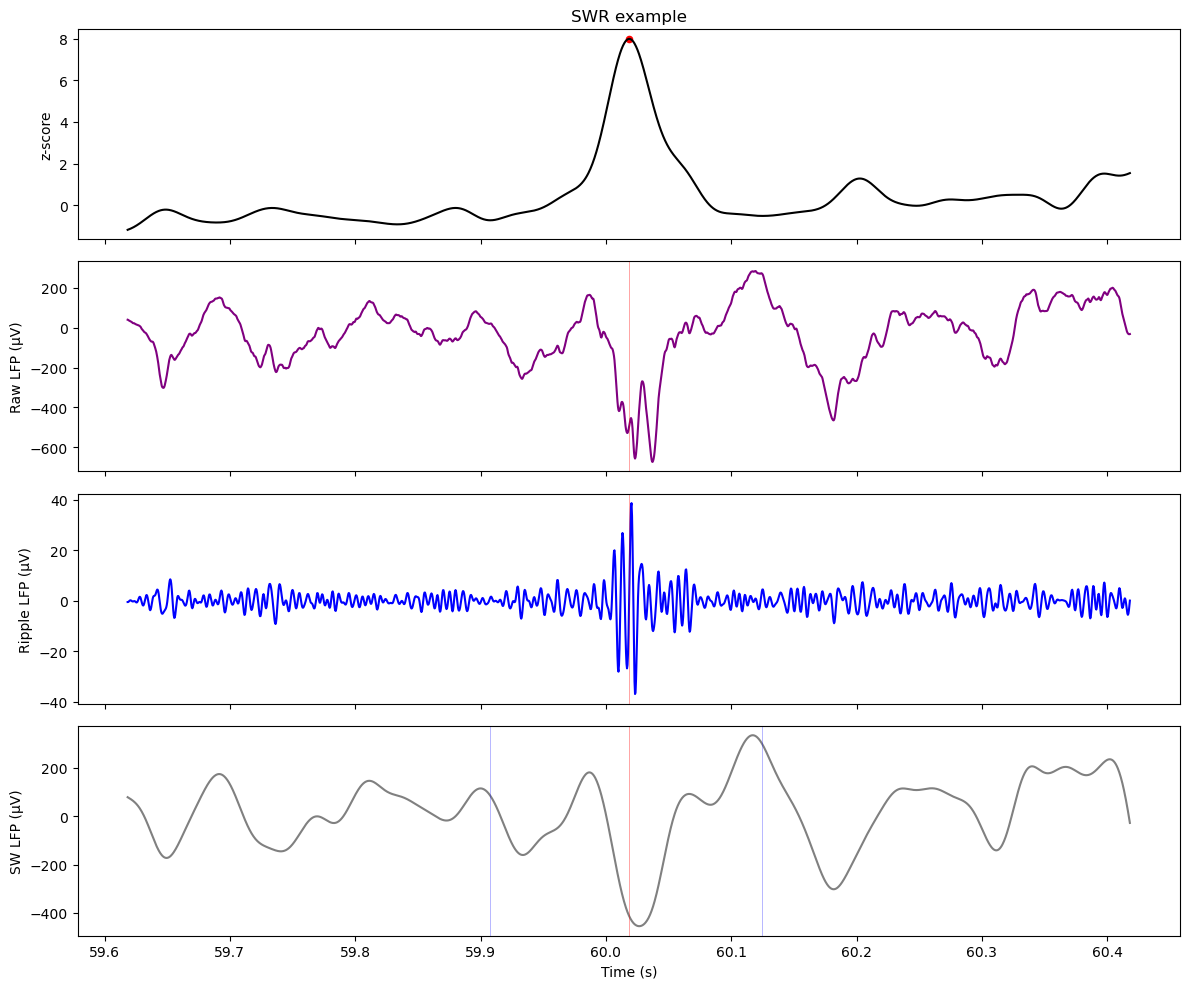

In [5]:
S = 0.195  # OpenEphys µV scaling
best = events.sort_values('peak_amp', ascending=False).iloc[0]
fig, _ = plot_ripple_triggered_lfp_for_example(
    lfp_z, lfp[2] * S, lfp_ripple[2:3] * S, lfp_sw[2:3] * S,
    events, fs=fs, xlim=(best.peak_time - 0.4, best.peak_time + 0.4),
)
fig.savefig(data_dir / 'seq006_1_1_postsleep_4740_4860s_example_swr.pdf', bbox_inches='tight')